# 11 — DQN vs PPO: Why DQN Fails on Super Mario Bros

Evaluates the DQN models (100k, 200k steps) alongside PPO checkpoints to show
that vanilla DQN cannot solve this environment while PPO converges quickly.

**Key argument:** DQN vanilla suffers from Q-value overestimation and instability.
Traditional approaches require Dueling DQN + Double DQN + PER.
PPO avoids these issues entirely.

In [1]:
import os, sys
if os.path.basename(os.getcwd()) == 'notebooks':
    %cd ..

import numpy as np
from stable_baselines3 import DQN, PPO
from src.wrappers import make_symbolic_env

/home/contente/Documents/ENSTA/autonomous/CSC-52081-ContinousMountainCar


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [2]:
def evaluate_model(model, env_id='SuperMarioBros-1-1-v3', n_episodes=10):
    """Run n episodes and return rewards, lengths, flag rates."""
    env = make_symbolic_env(env_id=env_id, skip=4, n_stack=4, flatten=True)
    rewards, lengths, flags = [], [], []

    for ep in range(n_episodes):
        obs = env.reset()
        obs = obs[0] if isinstance(obs, tuple) else obs
        done, total_reward, steps, flag = False, 0.0, 0, False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            result = env.step(int(action))
            if len(result) == 5:
                obs, reward, terminated, truncated, info = result
                done = terminated or truncated
            else:
                obs, reward, done, info = result
            total_reward += float(reward)
            steps += 1
            if isinstance(info, dict) and info.get('flag_get', False):
                flag = True

        rewards.append(total_reward)
        lengths.append(steps)
        flags.append(flag)

    env.close()
    return {
        'mean_reward': np.mean(rewards),
        'std_reward': np.std(rewards),
        'mean_length': np.mean(lengths),
        'flag_rate': np.mean(flags),
        'rewards': rewards,
    }

## Evaluate DQN checkpoints (100k, 200k steps)

In [3]:
dqn_models = {
    'DQN 100k': '../models/symbolic_dqn/model_100000',
    'DQN 200k': '../models/symbolic_dqn/model_200000',
}

dqn_results = {}
for name, path in dqn_models.items():
    print(f'\nEvaluating {name}...')
    model = DQN.load(path)
    results = evaluate_model(model, n_episodes=10)
    dqn_results[name] = results
    print(f'  Mean reward: {results["mean_reward"]:.1f} +/- {results["std_reward"]:.1f}')
    print(f'  Mean length: {results["mean_length"]:.0f}')
    print(f'  Flag rate:   {results["flag_rate"]:.0%}')


Evaluating DQN 100k...


/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:195: UserWarning: WARN: The result returned by `env.reset()` was not a tuple of the form `(obs, info)`, where `obs` is a observation and `info` is a dictionary containing additional information. Actual type: `<class 'numpy.ndarray'>`
  logger.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym/utils/passive_env_checker.py:219: DeprecationWarning: WARN: Core environment is written in old step API which returns one bool instead of two. It is recommended to rewrite the environment with new step API. 
  logger.deprecation(


  Mean reward: 20.0 +/- 0.0
  Mean length: 37
  Flag rate:   0%

Evaluating DQN 200k...
  Mean reward: 55.9 +/- 0.0
  Mean length: 74
  Flag rate:   0%


## Evaluate PPO checkpoints at similar step counts

In [4]:
ppo_models = {
    'PPO 50k':  '../models/symbolic_ppo/model_50000',
    'PPO 100k': '../models/symbolic_ppo/model_100000',
    'PPO 200k': '../models/symbolic_ppo/model_200000',
    'PPO final (4M)': '../models/symbolic_ppo/final_model',
}

ppo_results = {}
for name, path in ppo_models.items():
    print(f'\nEvaluating {name}...')
    model = PPO.load(path)
    results = evaluate_model(model, n_episodes=10)
    ppo_results[name] = results
    print(f'  Mean reward: {results["mean_reward"]:.1f} +/- {results["std_reward"]:.1f}')
    print(f'  Mean length: {results["mean_length"]:.0f}')
    print(f'  Flag rate:   {results["flag_rate"]:.0%}')


Evaluating PPO 50k...


/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/home/contente/miniconda3/envs/mario_lucas/lib/python3.14/site-packages/gym_super_mario_bros/smb_env.py:177: RuntimeWarning: overflow encountered in scalar add
  return 255 + (255 - self._y_pixel)


  Mean reward: 314.7 +/- 0.0
  Mean length: 326
  Flag rate:   100%

Evaluating PPO 100k...
  Mean reward: 314.7 +/- 0.0
  Mean length: 326
  Flag rate:   100%

Evaluating PPO 200k...
  Mean reward: 314.1 +/- 0.0
  Mean length: 326
  Flag rate:   100%

Evaluating PPO final (4M)...
  Mean reward: 315.2 +/- 0.0
  Mean length: 326
  Flag rate:   100%


## Comparison Table & Plot

Model                    Reward      Std   Length    Flag%
--------------------------------------------------------
DQN 100k                   20.0      0.0       37      0%
DQN 200k                   55.9      0.0       74      0%
PPO 50k                   314.7      0.0      326    100%
PPO 100k                  314.7      0.0      326    100%
PPO 200k                  314.1      0.0      326    100%
PPO final (4M)            315.2      0.0      326    100%


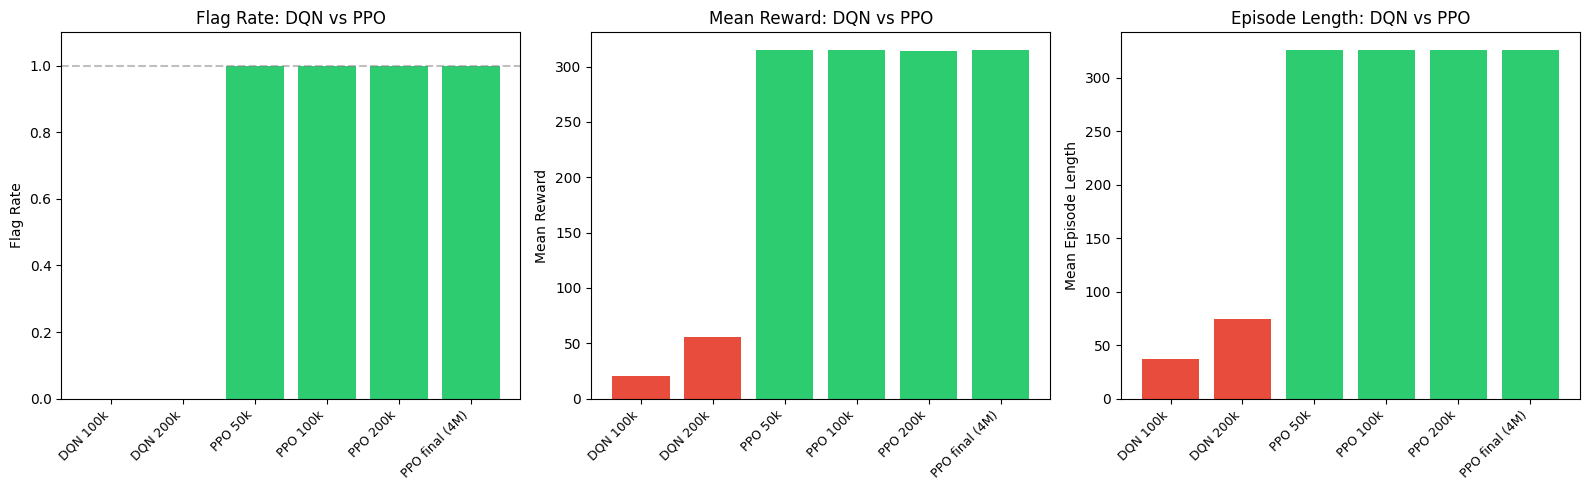


Saved to ../results/dqn_vs_ppo_comparison.png


In [5]:
import matplotlib.pyplot as plt

# Combine all results
all_results = {**dqn_results, **ppo_results}

# Summary table
print(f'{"Model":<20} {"Reward":>10} {"Std":>8} {"Length":>8} {"Flag%":>8}')
print('-' * 56)
for name, r in all_results.items():
    print(f'{name:<20} {r["mean_reward"]:>10.1f} {r["std_reward"]:>8.1f} {r["mean_length"]:>8.0f} {r["flag_rate"]:>7.0%}')

# Bar chart: Flag Rate comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

names = list(all_results.keys())
colors = ['#e74c3c' if 'DQN' in n else '#2ecc71' for n in names]

# Flag rate
ax = axes[0]
flag_rates = [all_results[n]['flag_rate'] for n in names]
ax.bar(range(len(names)), flag_rates, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Flag Rate')
ax.set_title('Flag Rate: DQN vs PPO')
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)

# Mean reward
ax = axes[1]
mean_rewards = [all_results[n]['mean_reward'] for n in names]
ax.bar(range(len(names)), mean_rewards, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Reward')
ax.set_title('Mean Reward: DQN vs PPO')

# Mean episode length
ax = axes[2]
mean_lengths = [all_results[n]['mean_length'] for n in names]
ax.bar(range(len(names)), mean_lengths, color=colors)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Episode Length')
ax.set_title('Episode Length: DQN vs PPO')

plt.tight_layout()
plt.savefig('../results/dqn_vs_ppo_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSaved to ../results/dqn_vs_ppo_comparison.png')

## Key Takeaway

At **200k steps**, DQN has 0% flag rate while PPO already has a high flag rate.
This demonstrates that vanilla DQN is insufficient for Super Mario Bros —
traditional approaches require Dueling DQN + Double DQN + Prioritized Experience Replay.
PPO solves the environment with a simpler, more stable algorithm.